今天我们来深入探讨一个在深度学习模型中至关重要，但也常常让初学者感到困惑的正则化技术——**权重衰退**。

我知道你们中有些人可能是刚接触这个领域，所以不用担心，我们会从最基础的概念开始，一步步把它讲清楚。我会先解释 **“为什么”** 需要它，然后再讲 **“是什么”**，最后是 **“怎么用”** 以及它 **“如何工作”**。

---

### 第一部分：问题的根源——过拟合

想象一下，你在准备一场考试。有一种学生，我们称他为“死记硬背型学生”。他把练习册上的每一道题，甚至每一个标点符号都背了下来。在考试时，如果遇到原题，他能得满分。但如果题目稍微变一下，或者出一道全新的题，他就完全不会了。

我们的深度学习模型，特别是那些参数极多、表达能力极强的模型（例如大型神经网络），就非常容易成为这种“死记硬背型学生”。这种现象我们称之为**过拟合**。

* **核心问题**：模型过于复杂，它不仅仅学会了数据中普遍的、通用的规律（这是我们想要的），还**记住了训练数据中的噪声和随机波动**（这是我们不想要的）。
* **结果**：模型在训练集上表现极好，但在从未见过的新数据（测试集）上表现糟糕。它的**泛化能力**很差。

**那么，我们如何阻止模型“死记硬背”，鼓励它“学习通用规律”呢？**
答案就是：**正则化**。而权重衰退，就是最常用、最有效的一种正则化方法。

---

### 第二部分：权重衰退的核心思想——奥卡姆剃刀原理

在科学领域，有一个著名的**奥卡姆剃刀原理**：**“如无必要，勿增实体”**。换句话说，在多个解释中，最简单、最简洁的那个往往是最好的。

把这个思想应用到我们的模型中：**如果一个简单的模型（例如参数值都很小）和一个复杂的模型（例如某些参数值非常大）在训练数据上表现差不多，那么我们应该倾向于选择简单的那个。** 因为简单的模型更可能捕捉到本质规律，而不是噪声。

**权重衰退就是通过强制让模型的权重（参数）变得更小，来实现这一点的。** 它通过在损失函数中添加一个“惩罚项”，来“惩罚”那些过大的权重值。

---

### 第三部分：权重衰退的数学定义

我们来正式定义它。一个标准的**损失函数**衡量的是模型预测值与真实值之间的差距，例如均方误差（MSE）或交叉熵损失。

**没有权重衰退的原始损失函数：**
$L = \frac{1}{N} \sum_{i=1}^{N} L(f(x_i; \mathbf{W}), y_i)$

其中，$L$ 是损失，$N$ 是样本数，$f$ 是模型，$\mathbf{W}$ 是所有权重参数，$x_i$ 和 $y_i$ 是数据和标签。

**添加了权重衰退的新损失函数：**
$L_{new} = L + \frac{\lambda}{2} ||\mathbf{W}||^2$

让我来分解这个公式：

1. **$L$**： 这是原来的损失项，确保模型要尽力拟合数据。
2. **$\frac{\lambda}{2} ||\mathbf{W}||^2$**： 这就是我们添加的**惩罚项**，也叫**L2正则化项**。
   * **$||\mathbf{W}||^2$**： 这是权重的 **L2范数的平方**。简单来说，它就是将所有权重值平方后求和。$\sum w_i^2$。大的权重值在平方后会变得非常大，所以模型会非常“不喜欢”大的权重，因为那会让整个损失函数变得很大。
   * **$\lambda$**： 这是一个超参数，叫做**权重衰退系数**或**正则化强度**。它是整个技术的核心控制器。
     * **如果 $\lambda = 0$**： 惩罚项消失，退回到原始损失函数，没有任何正则化效果。
     * **如果 $\lambda$ 太大**： 惩罚项占据主导地位，模型会过度“害怕”拥有大权重，最终所有权重都会趋近于0，导致模型变得过于简单，无法拟合任何数据，这称为**欠拟合**。
   * **$\frac{1}{2}$**： 这主要是为了求导后的形式更整洁，没有本质影响。

**所以，新的优化目标变成了一个权衡：不仅要让原来的损失L变小，还要让权重的平方和也变小。** 模型必须在“拟合数据”和“保持权重较小”之间找到一个最佳平衡。

---

### 第四部分：权重衰退如何工作——从梯度下降的角度理解

你们都知道，模型是通过**梯度下降**来学习的。它计算损失函数关于权重的梯度（导数），然后沿着梯度反方向更新权重，从而降低损失。

让我们看看添加了权重衰退后，权重更新规则发生了什么变化。

1. **计算梯度：**
   我们对新的损失函数 $L_{new}$ 求关于权重 $w$ 的梯度：
   $\frac{\partial L_{new}}{\partial w} = \frac{\partial L}{\partial w} + \lambda w$
2. **权重更新（原始）：**
   没有权重衰退时，更新规则是：
   $w \leftarrow w - \eta \frac{\partial L}{\partial w}$
   ($\eta$ 是学习率)
3. **权重更新（带权重衰退）：**
   现在，我们用新的梯度来更新：
   $w \leftarrow w - \eta (\frac{\partial L}{\partial w} + \lambda w)$

   我们可以把这个公式重新排列一下：
   $w \leftarrow (1 - \eta \lambda) w - \eta \frac{\partial L}{\partial w}$

**看！这个形式非常优美且富有启发性！**

在每次更新时，权重 $w$ 在沿着梯度方向更新之前，**会先被乘以一个小于1的因子 $(1 - \eta \lambda)$**。

* **这意味着什么？** 这意味着在每一步，权重都会先**自行衰减**，缩小一点点，然后再进行正常的梯度更新。
* **“权重衰退”这个名字正是来源于此**：权重在每一步都会有一个固定的、按比例的衰减。它就像一种“记忆衰退”，模型不会让任何一个权重变得特别大，除非它有非常充分的理由（即梯度 $\frac{\partial L}{\partial w}$ 非常持续且强大）。

这种机制有效地**限制了模型的复杂度**，防止了任何权重变得“失控”，从而实现了我们想要的简洁模型。

---

### 第五部分：一个生动的比喻

为了帮助你们记忆，可以这样想：

* **原始训练（无权重衰退）**：就像一个投资者，他只追求高回报（降低损失L），不顾风险，可能会把所有钱都押在一支高风险股票上（某个权重变得极大）。
* **带权重衰退的训练**：就像一个理性的投资者，他追求**高回报的同时，也要控制风险**。$\lambda$ 就是他的风险厌恶系数。
  * $\lambda$ 小： mildly厌恶风险，还是愿意为高回报下重注。
  * $\lambda$ 大： 极度厌恶风险，宁愿回报低一点，也要把资金分散开（让所有权重都变小）。

这个惩罚项 $\frac{\lambda}{2} ||\mathbf{W}||^2$ 就是他的“风险控制部门”。

---

### 第六部分：如何在实践中使用权重衰退

在几乎所有现代深度学习框架（如PyTorch, TensorFlow）中，实现权重衰退都异常简单。它通常被集成在优化器里。

例如，在PyTorch中，当你初始化优化器时，直接指定 `weight_decay` 参数即可：

```python
import torch.optim as optim

# lambda 就是这里的 weight_decay 参数
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.001) # 设置 λ = 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01) # Adam优化器也可以
```

**关键步骤：寻找最优的 $\lambda$**
$\lambda$ 是一个超参数，没有绝对正确的值。你需要通过**验证集**进行**超参数调优**来找到它。

* 常见的尝试范围可能在 $10^{-1}$， $10^{-2}$， $10^{-3}$， $10^{-4}$ 数量级。
* 从一个值（如 `0.01` 或 `0.001`)开始，根据模型在验证集上的表现（而不是训练集！）来增大或减小它。

### 总结

同学们，记住权重衰退的要点：

1. **目标**： 防止过拟合，提高模型泛化能力。
2. **思想**： 奥卡姆剃刀原理，偏好简单模型。
3. **方法**： 在损失函数中添加一个L2惩罚项 $\frac{\lambda}{2} ||\mathbf{W}||^2$。
4. **效果**： 在梯度下降过程中，它等价于在每次更新前先让权重进行一次衰减 ($w \leftarrow (1 - \eta \lambda) w$)。
5. **控制**： 通过超参数 $\lambda$ 控制正则化强度，需要仔细调优。

权重衰退是一种非常直观、数学上优雅且极其有效的技术，是每一个深度学习实践者工具箱里的必备工具。希望这次的解释能让大家彻底理解它。

w的L2范数是： 12.678933143615723


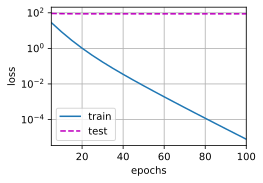

In [7]:
%matplotlib inline

import torch
from torch import nn
from d2l import torch as d2l

n_train,n_test,num_inputs,batch_size = 20,100,200,5
true_w,true_b = torch.ones((num_inputs,1)) * 0.01,0.05
train_data = d2l.synthetic_data(true_w,true_b,n_train)
train_iter = d2l.load_array(train_data,batch_size)
test_data = d2l.synthetic_data(true_w,true_b,n_test)
test_iter = d2l.load_array(test_data,batch_size,is_train=False)



def init_params() : 
    w = torch.normal(0,1,size=(num_inputs,1),requires_grad=True)
    b = torch.zeros(1,requires_grad=True)
    return [w,b]

# L2范数惩罚
def l2_penalty(w) : 
    return torch.sum(w.pow(2))/2

def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())
    
    
train(lambd=0)




w的L2范数是： 0.37354540824890137


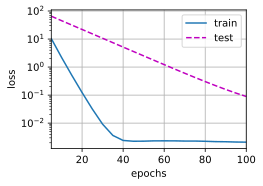

In [13]:
train(lambd = 3)